In [64]:
import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 15)

pd.options.display.max_colwidth = 15

import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [119]:
from sklearn.datasets import make_regression

X, y, true_coef = make_regression(
    n_samples=100,
    n_features=20,
    n_informative=15,      # Only 5 features actually matter
    effective_rank = 10,
    n_targets=1,
    bias=10.0,
    noise=20,           # Moderate noise
    shuffle=True,
    coef=True,
    random_state=42
)

data_dict = {f'x{n}':X[:,n] for n in range(X.shape[1])}
data_dict['y'] = y
data_df = pd.DataFrame(data_dict)

# sns.pairplot(data_df)
# plt.show()



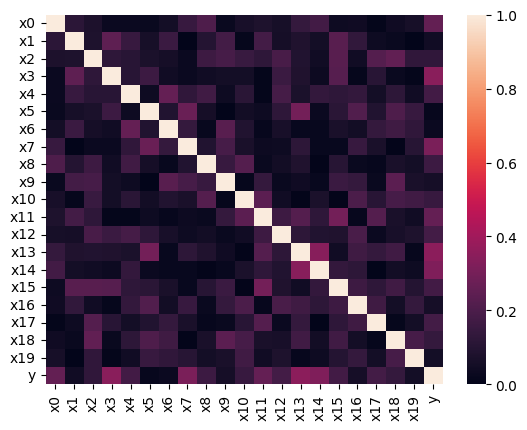

In [120]:
dcorr = data_df.corr()

sns.heatmap(np.abs(dcorr), vmin = 0, vmax =1)
plt.show()

In [121]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

sc = StandardScaler()
sc.fit(X_train)

Z_train = sc.transform(X_train)
Z_test = sc.transform(X_test)

alpha = np.logspace(-2,5,51)
print(alpha)

linreg = LinearRegression()
linreg.fit(Z_train, y_train)

lasso = LassoCV(alphas = alpha)
lasso.fit(Z_train, y_train)

ridge = RidgeCV(alphas = alpha)
ridge.fit(Z_train, y_train)

[1.00000000e-02 1.38038426e-02 1.90546072e-02 2.63026799e-02
 3.63078055e-02 5.01187234e-02 6.91830971e-02 9.54992586e-02
 1.31825674e-01 1.81970086e-01 2.51188643e-01 3.46736850e-01
 4.78630092e-01 6.60693448e-01 9.12010839e-01 1.25892541e+00
 1.73780083e+00 2.39883292e+00 3.31131121e+00 4.57088190e+00
 6.30957344e+00 8.70963590e+00 1.20226443e+01 1.65958691e+01
 2.29086765e+01 3.16227766e+01 4.36515832e+01 6.02559586e+01
 8.31763771e+01 1.14815362e+02 1.58489319e+02 2.18776162e+02
 3.01995172e+02 4.16869383e+02 5.75439937e+02 7.94328235e+02
 1.09647820e+03 1.51356125e+03 2.08929613e+03 2.88403150e+03
 3.98107171e+03 5.49540874e+03 7.58577575e+03 1.04712855e+04
 1.44543977e+04 1.99526231e+04 2.75422870e+04 3.80189396e+04
 5.24807460e+04 7.24435960e+04 1.00000000e+05]


,alphas,array([1.0000...00000000e+05])
,fit_intercept,True
,scoring,None
,cv,None
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [122]:
y_linreg = linreg.predict(Z_test)
r2_linreg = r2_score(y_test, y_linreg)
rmse_linreg = root_mean_squared_error(y_test, y_linreg)

y_ridge = ridge.predict(Z_test)
r2_ridge = r2_score(y_test, y_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_ridge)

y_lasso = lasso.predict(Z_test)
r2_lasso = r2_score(y_test, y_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_lasso)

print(f'R2\nlinreg:\t{r2_linreg:0.2f}\nridge:\t{r2_ridge:0.2f}\nlasso:\t{r2_lasso:0.2f}')
print(f'RMSE\nlinreg:\t{rmse_linreg:0.2f}\nridge:\t{rmse_ridge:0.2f}\nlasso:\t{rmse_lasso:0.2f}')


R2
linreg:	0.32
ridge:	0.35
lasso:	0.34
RMSE
linreg:	23.77
ridge:	23.22
lasso:	23.46


In [123]:



coef_dict = {f'True': true_coef,
             f'LinReg': linreg.coef_,
             f'Ridge {ridge.alpha_:0.2f}': ridge.coef_,
             f'Lasso {lasso.alpha_:0.2f}': lasso.coef_
}

coef_df = pd.DataFrame(coef_dict)
coef_df

,True,LinReg,Ridge 31.62,Lasso 0.48
0,62.36,4.43,3.38,3.93
1,0.00,-2.37,-0.47,-1.29
2,1.51,3.44,1.91,2.47
3,95.14,10.18,7.10,9.50
4,60.36,4.41,2.74,3.70
5,9.21,-2.69,-1.61,-2.16
6,29.73,-0.28,0.22,0.00
7,26.74,5.92,4.41,5.61
8,0.00,1.81,1.96,1.85
9,0.00,-0.20,0.47,0.00


In [90]:
housing_df = pd.read_csv('https://raw.githubusercontent.com/GettysburgDataScience/datasets/refs/heads/main/kc_house_data.csv')

housing_df = housing_df.query('2<=bedrooms<=6')
zipcode_df = pd.get_dummies(housing_df['zipcode'], prefix = 'zip', dtype = int)

housing_df.drop(columns = ['id', 'date', 'zipcode', 'yr_renovated', 'yr_built', 'lat', 'long'], inplace = True)
housing_df = housing_df.join(zipcode_df)

housing_df



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
0,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,...,0,0,0,0,0,0,1,0,0,0
1,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,...,0,0,0,0,0,0,0,0,0,0
2,180000.00,2,1.00,770,10000,1.00,0,0,3,6,...,0,0,0,0,0,0,0,0,0,0
3,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,...,0,0,0,0,0,0,0,0,0,0
4,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.00,3,2.50,1530,1131,3.00,0,0,3,8,...,0,0,0,0,0,0,0,0,0,0
21609,400000.00,4,2.50,2310,5813,2.00,0,0,3,8,...,1,0,0,0,0,0,0,0,0,0
21610,402101.00,2,0.75,1020,1350,2.00,0,0,3,7,...,0,0,0,0,0,0,0,0,0,0
21611,400000.00,3,2.50,1600,2388,2.00,0,0,3,8,...,0,0,0,0,0,0,0,0,0,0


In [19]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

In [20]:
y = housing_df['price']
X = housing_df.drop(columns='price')

alphas = np.logspace(-2,3,51)
alphas

array([1.00000000e-02, 1.25892541e-02, 1.58489319e-02, 1.99526231e-02,
       2.51188643e-02, 3.16227766e-02, 3.98107171e-02, 5.01187234e-02,
       6.30957344e-02, 7.94328235e-02, 1.00000000e-01, 1.25892541e-01,
       1.58489319e-01, 1.99526231e-01, 2.51188643e-01, 3.16227766e-01,
       3.98107171e-01, 5.01187234e-01, 6.30957344e-01, 7.94328235e-01,
       1.00000000e+00, 1.25892541e+00, 1.58489319e+00, 1.99526231e+00,
       2.51188643e+00, 3.16227766e+00, 3.98107171e+00, 5.01187234e+00,
       6.30957344e+00, 7.94328235e+00, 1.00000000e+01, 1.25892541e+01,
       1.58489319e+01, 1.99526231e+01, 2.51188643e+01, 3.16227766e+01,
       3.98107171e+01, 5.01187234e+01, 6.30957344e+01, 7.94328235e+01,
       1.00000000e+02, 1.25892541e+02, 1.58489319e+02, 1.99526231e+02,
       2.51188643e+02, 3.16227766e+02, 3.98107171e+02, 5.01187234e+02,
       6.30957344e+02, 7.94328235e+02, 1.00000000e+03])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

sc = StandardScaler()
sc.fit(X_train)

Z_train = sc.transform(X_train)
Z_test = sc.transform(X_test)

alpha = np.logspace(-2,5,51)
print(alpha)

linreg = LinearRegression()
linreg.fit(Z_train, y_train)

lasso = LassoCV(alphas = alpha)
lasso.fit(Z_train, y_train)

ridge = RidgeCV(alphas = alpha)
ridge.fit(Z_train, y_train)


[1.00000000e-02 1.38038426e-02 1.90546072e-02 2.63026799e-02
 3.63078055e-02 5.01187234e-02 6.91830971e-02 9.54992586e-02
 1.31825674e-01 1.81970086e-01 2.51188643e-01 3.46736850e-01
 4.78630092e-01 6.60693448e-01 9.12010839e-01 1.25892541e+00
 1.73780083e+00 2.39883292e+00 3.31131121e+00 4.57088190e+00
 6.30957344e+00 8.70963590e+00 1.20226443e+01 1.65958691e+01
 2.29086765e+01 3.16227766e+01 4.36515832e+01 6.02559586e+01
 8.31763771e+01 1.14815362e+02 1.58489319e+02 2.18776162e+02
 3.01995172e+02 4.16869383e+02 5.75439937e+02 7.94328235e+02
 1.09647820e+03 1.51356125e+03 2.08929613e+03 2.88403150e+03
 3.98107171e+03 5.49540874e+03 7.58577575e+03 1.04712855e+04
 1.44543977e+04 1.99526231e+04 2.75422870e+04 3.80189396e+04
 5.24807460e+04 7.24435960e+04 1.00000000e+05]


,alphas,array([1.0000...00000000e+05])
,fit_intercept,True
,scoring,None
,cv,None
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [22]:
y_linreg = linreg.predict(Z_test)
r2_linreg = r2_score(y_test, y_linreg)
rmse_linreg = root_mean_squared_error(y_test, y_linreg)

y_ridge = ridge.predict(Z_test)
r2_ridge = r2_score(y_test, y_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_ridge)

y_lasso = lasso.predict(Z_test)
r2_lasso = r2_score(y_test, y_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_lasso)

print(f'R2\nlinreg:\t{r2_linreg:0.2f}\nridge:\t{r2_ridge:0.2f}\nlasso:\t{r2_lasso:0.2f}')
print(f'RMSE\nlinreg:\t{rmse_linreg:0.2f}\nridge:\t{rmse_ridge:0.2f}\nlasso:\t{rmse_lasso:0.2f}')

R2
linreg:	0.79
ridge:	0.79
lasso:	0.79
RMSE
linreg:	162518.72
ridge:	161209.20
lasso:	162329.79


In [23]:
features = [col for col in X.columns if not col.startswith('zip')]
zipcodes = [col for col in X.columns if col.startswith('zip')]

num_features = len(features)
num_zips = len(zipcodes)


coef_dict = {'feature name': features,
             f'LinReg': linreg.coef_[0:num_features],
             f'Ridge {ridge.alpha_:0.2f}': ridge.coef_[0:num_features],
             f'Lasso {lasso.alpha_:0.2f}': lasso.coef_[0:num_features]
}

coef_df = pd.DataFrame(coef_dict)
coef_df


,feature name,LinReg,Ridge 43.65,Lasso 416.87
0,bedrooms,-27072.66,-23616.21,-25839.30
1,bathrooms,1711.71,4110.26,394.93
2,sqft_living,121911.27,117626.17,171419.45
3,sqft_lot,40240.62,38765.74,38555.07
4,floors,-47899.14,-43540.57,-45998.16
5,waterfront,70469.47,68933.74,70095.89
6,view,50763.35,50431.24,50695.51
7,condition,24047.98,23592.58,23656.53
8,grade,78983.58,77857.26,78583.69
9,sqft_above,138978.42,132907.36,99030.62


In [24]:
zip_dict = {'zipcode' : zipcodes,
            'LinReg' : linreg.coef_[-num_zips:],
            'Ridge' : ridge.coef_[-num_zips:],
            'Lasso' : lasso.coef_[-num_zips:]}

zip_df = pd.DataFrame(zip_dict)
zip_df.sort_values(by = 'Lasso', ascending = False).head(20)

zip_list = [98105, 98103, 98119, 98115, 98199, 98033, 98102]

In [25]:
# cars_df = pd.read_csv('https://raw.githubusercontent.com/shreyamdg/automobile-data-set-analysis/refs/heads/master/cars.csv')
# columns_to_keep = cars_df.columns[3:]
# cars_df = data_df[columns_to_keep]

# # cars_df = cars_df[cars_df['fuel-type']=='gas']
# cars_df = cars_df.query('`fuel-type`== "gas"')

# cars_df = cars_df.select_dtypes(include = np.number) 
# cars_df.head()

In [26]:
# target = ['city-mpg']

# X = cars_df.drop(columns = ['city-mpg', 'highway-mpg'])
# y = cars_df[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# sc = StandardScaler()
# sc.fit(X_train)

# Z_train = sc.transform(X_train)
# Z_test = sc.transform(X_test)

# classo = LassoCV(alphas=alphas)
# classo.fit(Z_train, y_train)